# AgentCore Memory Metrics - Comprehensive Analysis

## Overview

This notebook provides exhaustive monitoring of **AWS Bedrock AgentCore Memory** metrics. After completing Labs 1-3, your AgentCore Memory resource automatically emits detailed metrics to Amazon CloudWatch.

## What You'll Learn

- ✅ **CloudWatch Concepts**: Dimensions, Operations, Metrics, Namespace
- ✅ **Memory Operations**: All 6 operations including RetrieveMemoryRecords
- ✅ **Console Navigation**: Step-by-step CloudWatch console access
- ✅ **Comprehensive Querying**: Query ALL dimension combinations
- ✅ **Visualization**: Charts, dashboards, and trend analysis

## Prerequisites

- ✅ Completed Lab 2 (AgentCore Memory)
- ✅ AgentCore Memory resource deployed
- ✅ Some memory activity (conversation history)
- ✅ AWS CloudWatch access permissions

## 📚 CloudWatch Concepts for AgentCore Memory

Before diving into metrics, let's understand the key concepts:

### 🏷️ **Dimensions**
Dimensions are **key-value pairs** that uniquely identify a metric. Think of them as "filters" or "tags":

```python
# Examples of Memory dimensions:
{
    'Resource': 'arn:aws:bedrock-agentcore:us-east-1:123456789012:memory/MyMemory-ABC123',
    'Operation': 'RetrieveMemoryRecords'  # The specific API operation
}

{
    'ItemType': 'Event',  # Type of memory item being tracked
    'StrategyType': 'DefaultMemoryStrategy'  # Memory strategy used
}
```

### ⚙️ **Operations** 
Operations are **specific API actions** that AgentCore Memory performs:

| Operation | Description | When It Happens |
|-----------|-------------|----------------|
| `CreateEvent` | Creates new conversation events | Every user/assistant interaction |
| `GetMemory` | Retrieves existing memories | When agent needs context |
| `RetrieveMemoryRecords` | Searches memory for relevant info | During agent responses |
| `Consolidation` | Merges and organizes memories | Background memory processing |
| `Extraction` | Extracts key info from conversations | Background memory processing |
| `CreateMemory` | Creates new memory instances | Memory initialization |

### 📊 **Metrics**
Metrics are the **actual measurements** collected:

| Metric Name | Unit | Description |
|-------------|------|-------------|
| `Invocations` | Count | How many times the operation was called |
| `Latency` | Milliseconds | Time from request to first response |
| `Duration` | Milliseconds | Total time for complete operation |
| `CreationCount` | Count | Number of memory items created |
| `Errors` | Count | Total errors (4xx + 5xx) |
| `SystemErrors` | Count | AWS server-side errors (5xx) |
| `UserErrors` | Count | Client-side errors (4xx, except throttles) |
| `Throttles` | Count | Requests rejected due to rate limiting |

### 🏠 **Namespace**
All AgentCore metrics live in: **`AWS/Bedrock-AgentCore`**

## Step 1: Setup and Resource Discovery

In [1]:
import boto3
import json
import pandas as pd
from datetime import datetime, timedelta, timezone
from typing import Dict, List, Optional, Tuple
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown, HTML

# Import utilities for getting lab resources
from scripts.utils import get_ssm_parameter

# Initialize AWS clients
session = boto3.Session()
region = session.region_name
account_id = boto3.client('sts').get_caller_identity()['Account']
cloudwatch = boto3.client('cloudwatch', region_name=region)

print(f"✅ Connected to AWS Account: {account_id}")
print(f"📍 Region: {region}")
print(f"📊 CloudWatch Namespace: AWS/Bedrock-AgentCore")

# Configure plotting
plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline

✅ Connected to AWS Account: 533267284022
📍 Region: us-east-1
📊 CloudWatch Namespace: AWS/Bedrock-AgentCore


In [2]:
def get_memory_resource() -> Dict[str, str]:
    """Get Memory resource details from Lab 2"""
    
    try:
        memory_id = get_ssm_parameter("/app/customersupport/agentcore/memory_id")
        memory_arn = f"arn:aws:bedrock-agentcore:{region}:{account_id}:memory/{memory_id}"
        
        print(f"✅ Found AgentCore Memory Resource:")
        print(f"   🆔 Memory ID: {memory_id}")
        print(f"   🔗 Memory ARN: {memory_arn}")
        
        return {
            'memory_id': memory_id,
            'memory_arn': memory_arn
        }
        
    except Exception as e:
        print(f"❌ Memory resource not found: {str(e)}")
        print(f"   Please complete Lab 2 first to create AgentCore Memory")
        return {}

# Get memory resource
memory_resource = get_memory_resource()

✅ Found AgentCore Memory Resource:
   🆔 Memory ID: CustomerSupportMemory-WcEhTTFp1O
   🔗 Memory ARN: arn:aws:bedrock-agentcore:us-east-1:533267284022:memory/CustomerSupportMemory-WcEhTTFp1O


## Step 2: Discover ALL Available Memory Metrics

Let's discover what metrics and operations are actually available for your memory resource:

In [3]:
def discover_memory_metrics_complete(memory_arn: str) -> Dict:
    """Discover ALL available metrics, operations, and dimensions for Memory"""
    
    if not memory_arn:
        print("⚠️ No Memory ARN available")
        return {}
    
    print(f"🔍 Discovering ALL Memory Metrics and Operations")
    print(f"🔗 Resource: {memory_arn}")
    print("-" * 70)
    
    discovered = {
        'metrics': {},
        'operations': set(),
        'dimensions': set(),
        'item_types': set(),
        'strategy_types': set()
    }
    
    try:
        # Find all metrics for this memory resource
        response = cloudwatch.list_metrics(
            Namespace='AWS/Bedrock-AgentCore',
            Dimensions=[
                {'Name': 'Resource', 'Value': memory_arn}
            ]
        )
        
        print(f"✅ Found {len(response['Metrics'])} metric combinations")
        print()
        
        # Analyze each metric
        for metric in response['Metrics']:
            metric_name = metric['MetricName']
            
            if metric_name not in discovered['metrics']:
                discovered['metrics'][metric_name] = []
            
            # Extract dimension information
            dim_combo = {}
            for dim in metric['Dimensions']:
                dim_combo[dim['Name']] = dim['Value']
                discovered['dimensions'].add(dim['Name'])
                
                # Collect specific dimension values
                if dim['Name'] == 'Operation':
                    discovered['operations'].add(dim['Value'])
                elif dim['Name'] == 'ItemType':
                    discovered['item_types'].add(dim['Value'])
                elif dim['Name'] == 'StrategyType':
                    discovered['strategy_types'].add(dim['Value'])
            
            discovered['metrics'][metric_name].append(dim_combo)
        
        # Display comprehensive summary
        print(f"📈 **Available Metrics**: {', '.join(sorted(discovered['metrics'].keys()))}")
        print(f"📐 **Dimensions Used**: {', '.join(sorted(discovered['dimensions']))}")
        
        if discovered['operations']:
            print(f"\n⚙️ **Memory Operations Found** ({len(discovered['operations'])}):**")
            for i, op in enumerate(sorted(discovered['operations']), 1):
                print(f"   {i}. {op}")
        
        if discovered['item_types']:
            print(f"\n📦 **Item Types**: {', '.join(sorted(discovered['item_types']))}")
            
        if discovered['strategy_types']:
            print(f"🧠 **Strategy Types**: {', '.join(sorted(discovered['strategy_types']))}")
        
        # Show detailed metric breakdown
        print(f"\n📊 **Detailed Metric Configurations**:")
        for metric_name, combinations in discovered['metrics'].items():
            print(f"\n**{metric_name}** ({len(combinations)} combinations):")
            for combo in combinations[:5]:  # Show first 5
                dims = [f"{k}={v.split('/')[-1] if '/' in v else v}" 
                       for k, v in combo.items() if k != 'Resource']
                dim_str = ', '.join(dims) if dims else 'Base metric'
                print(f"   • {dim_str}")
            if len(combinations) > 5:
                print(f"   ... and {len(combinations) - 5} more")
    
    except Exception as e:
        print(f"❌ Error discovering metrics: {str(e)}")
    
    return discovered

# Discover all memory metrics
if memory_resource:
    memory_discovery = discover_memory_metrics_complete(memory_resource['memory_arn'])
else:
    memory_discovery = {}

🔍 Discovering ALL Memory Metrics and Operations
🔗 Resource: arn:aws:bedrock-agentcore:us-east-1:533267284022:memory/CustomerSupportMemory-WcEhTTFp1O
----------------------------------------------------------------------
✅ Found 18 metric combinations

📈 **Available Metrics**: CreationCount, Invocations, Latency
📐 **Dimensions Used**: ItemType, Operation, Resource, StrategyId, StrategyType

⚙️ **Memory Operations Found** (6):**
   1. Consolidation
   2. CreateEvent
   3. CreateMemory
   4. Extraction
   5. GetMemory
   6. RetrieveMemoryRecords

📦 **Item Types**: Event, MemoryRecordsExtracted
🧠 **Strategy Types**: Preference, Semantic

📊 **Detailed Metric Configurations**:

**Invocations** (8 combinations):
   • Operation=CreateMemory
   • Operation=GetMemory
   • StrategyType=Semantic, StrategyId=CustomerSupportSemantic-EY0g3nEgr0, Operation=Consolidation
   • StrategyType=Semantic, StrategyId=CustomerSupportSemantic-EY0g3nEgr0, Operation=Extraction
   • StrategyType=Preference, Strateg

## Step 3: Query Memory Metrics Exhaustively

Now let's query ALL metrics with their proper dimension combinations:

In [4]:
def query_memory_metrics_exhaustive(memory_arn: str, memory_id: str, hours_back: int = 24) -> Dict:
    """Query Memory metrics with ALL possible dimension combinations"""
    
    if not memory_arn:
        print("⚠️ No Memory ARN available")
        return {}
    
    print(f"📊 Querying ALL Memory Metrics (Last {hours_back} hours)")
    print(f"🔗 Resource: {memory_arn}")
    print(f"🆔 Memory ID: {memory_id}")
    print("-" * 70)
    
    end_time = datetime.now(timezone.utc)
    start_time = end_time - timedelta(hours=hours_back)
    
    # All possible dimension combinations based on AWS documentation
    dimension_sets = [
        # 1. Resource-only (base metrics)
        [{'Name': 'Resource', 'Value': memory_arn}],
        
        # 2. Resource + Operation (most important - includes RetrieveMemoryRecords!)
        [{'Name': 'Resource', 'Value': memory_arn}, {'Name': 'Operation', 'Value': 'CreateEvent'}],
        [{'Name': 'Resource', 'Value': memory_arn}, {'Name': 'Operation', 'Value': 'GetMemory'}],
        [{'Name': 'Resource', 'Value': memory_arn}, {'Name': 'Operation', 'Value': 'RetrieveMemoryRecords'}],  # This was missing!
        [{'Name': 'Resource', 'Value': memory_arn}, {'Name': 'Operation', 'Value': 'Consolidation'}],
        [{'Name': 'Resource', 'Value': memory_arn}, {'Name': 'Operation', 'Value': 'Extraction'}],
        [{'Name': 'Resource', 'Value': memory_arn}, {'Name': 'Operation', 'Value': 'CreateMemory'}],
        
        # 3. ItemType dimensions
        [{'Name': 'Resource', 'Value': memory_arn}, {'Name': 'ItemType', 'Value': 'Event'}],
        [{'Name': 'Resource', 'Value': memory_arn}, {'Name': 'ItemType', 'Value': 'MemoryRecordsExtracted'}],
        [{'Name': 'ItemType', 'Value': 'Event'}],
        [{'Name': 'ItemType', 'Value': 'MemoryRecordsExtracted'}],
        
        # 4. Strategy-based dimensions
        [{'Name': 'Resource', 'Value': memory_arn}, {'Name': 'StrategyType', 'Value': 'DefaultMemoryStrategy'}],
    ]
    
    # All metrics to query based on AWS documentation
    metrics_to_query = [
        ('Invocations', 'Sum', 'Total API requests and memory ingestion events'),
        ('Latency', 'Average', 'Time from request to first response token (ms)'),
        ('Duration', 'Average', 'Complete end-to-end processing time (ms)'),
        ('CreationCount', 'Sum', 'Number of memory events and records created'),
        ('Errors', 'Sum', 'Total errors during API requests and ingestion'),
        ('SystemErrors', 'Sum', 'AWS server-side errors (5xx)'),
        ('UserErrors', 'Sum', 'Client-side errors (4xx except throttles)'),
        ('Throttles', 'Sum', 'Requests rejected due to rate limiting')
    ]
    
    results = {}
    total_found = 0
    
    for i, dimensions in enumerate(dimension_sets, 1):
        # Create readable dimension string
        dim_parts = []
        for d in dimensions:
            if d['Name'] == 'Resource':
                dim_parts.append(f"Resource={memory_id}")
            else:
                dim_parts.append(f"{d['Name']}={d['Value']}")
        dim_str = ', '.join(dim_parts)
        
        print(f"\n🔍 **Query {i}/{len(dimension_sets)}**: {dim_str}")
        
        found_metrics = []
        for metric_name, statistic, description in metrics_to_query:
            try:
                response = cloudwatch.get_metric_statistics(
                    Namespace='AWS/Bedrock-AgentCore',
                    MetricName=metric_name,
                    Dimensions=dimensions,
                    StartTime=start_time,
                    EndTime=end_time,
                    Period=3600,  # 1 hour periods
                    Statistics=[statistic]
                )
                
                datapoints = response.get('Datapoints', [])
                if datapoints:
                    sorted_points = sorted(datapoints, key=lambda x: x['Timestamp'])
                    latest = sorted_points[-1][statistic]
                    
                    found_metrics.append({
                        'metric': metric_name,
                        'value': latest,
                        'description': description,
                        'datapoints': len(datapoints)
                    })
                    
                    # Store in results
                    key = f"{metric_name}_{dim_str}"
                    results[key] = {
                        'metric_name': metric_name,
                        'dimensions': dimensions,
                        'datapoints': sorted_points,
                        'latest_value': latest,
                        'description': description
                    }
                    
            except Exception as e:
                continue  # Skip failed queries
        
        if found_metrics:
            for metric_info in found_metrics:
                print(f"   ✅ **{metric_info['metric']}**: {metric_info['value']:.2f} ({metric_info['datapoints']} data points)")
                print(f"      {metric_info['description']}")
            total_found += len(found_metrics)
        else:
            print(f"   ℹ️ No data found")
    
    print(f"\n🎉 **Summary**: Found {total_found} metrics across {len(dimension_sets)} dimension combinations")
    return results

# Query all memory metrics
if memory_resource:
    memory_metrics = query_memory_metrics_exhaustive(
        memory_resource['memory_arn'], 
        memory_resource['memory_id']
    )
else:
    memory_metrics = {}

📊 Querying ALL Memory Metrics (Last 24 hours)
🔗 Resource: arn:aws:bedrock-agentcore:us-east-1:533267284022:memory/CustomerSupportMemory-WcEhTTFp1O
🆔 Memory ID: CustomerSupportMemory-WcEhTTFp1O
----------------------------------------------------------------------

🔍 **Query 1/12**: Resource=CustomerSupportMemory-WcEhTTFp1O
   ℹ️ No data found

🔍 **Query 2/12**: Resource=CustomerSupportMemory-WcEhTTFp1O, Operation=CreateEvent
   ✅ **Invocations**: 5.00 (2 data points)
      Total API requests and memory ingestion events
   ✅ **Latency**: 59.80 (2 data points)
      Time from request to first response token (ms)

🔍 **Query 3/12**: Resource=CustomerSupportMemory-WcEhTTFp1O, Operation=GetMemory
   ✅ **Invocations**: 2.00 (3 data points)
      Total API requests and memory ingestion events
   ✅ **Latency**: 42.50 (3 data points)
      Time from request to first response token (ms)

🔍 **Query 4/12**: Resource=CustomerSupportMemory-WcEhTTFp1O, Operation=RetrieveMemoryRecords
   ✅ **Invocation

## Step 4: 🖥️ CloudWatch Console Navigation Guide

Here's how to access these same metrics in the AWS CloudWatch console:

In [5]:
def generate_console_navigation_guide(memory_id: str, region: str) -> None:
    """Generate CloudWatch console navigation URLs and instructions"""
    
    if not memory_id:
        print("⚠️ No Memory ID available for console navigation")
        return
    
    print(f"🖥️ **CloudWatch Console Navigation Guide**")
    print(f"📍 Region: {region}")
    print(f"🆔 Memory ID: {memory_id}")
    print("-" * 70)
    
    # Base CloudWatch metrics URL
    base_url = f"https://{region}.console.aws.amazon.com/cloudwatch/home?region={region}"
    
    print(f"### 📊 **Method 1: Direct Metric URLs**")
    print()
    
    # Specific URLs for different views
    urls = {
        "All AgentCore Metrics": f"{base_url}#metricsV2?graph=~()&query=~'*7bAWS*2fBedrock-AgentCore*7d",
        "Memory-Specific Metrics": f"{base_url}#metricsV2?graph=~()&query=~'*7bAWS*2fBedrock-AgentCore*2cResource*7d&search={memory_id}",
        "RetrieveMemoryRecords Operations": f"{base_url}#metricsV2?graph=~()&query=~'*7bAWS*2fBedrock-AgentCore*2cResource*2cOperation*7d&search=RetrieveMemoryRecords"
    }
    
    for name, url in urls.items():
        print(f"**{name}:**")
        print(f"```")
        print(f"{url}")
        print(f"```")
        print()
    
    print(f"### 📋 **Method 2: Manual Navigation Steps**")
    print()
    print(f"1. **Open CloudWatch Console**:")
    print(f"   - Go to AWS Console → CloudWatch")
    print(f"   - Or use: {base_url}")
    print()
    print(f"2. **Navigate to Metrics**:")
    print(f"   - Left sidebar → 'Metrics' → 'All metrics'")
    print(f"   - In search box, type: `AWS/Bedrock-AgentCore`")
    print()
    print(f"3. **Filter by Resource**:")
    print(f"   - Click on 'By Dimension' tab")
    print(f"   - Select 'Resource' dimension")
    print(f"   - Search for: `{memory_id}`")
    print()
    print(f"4. **View Specific Operations**:")
    print(f"   - Click 'Resource, Operation' dimension combination")
    print(f"   - Look for operations like:")
    
    operations = ['RetrieveMemoryRecords', 'CreateEvent', 'GetMemory', 'Consolidation', 'Extraction']
    for op in operations:
        print(f"     • {op}")
    
    print()
    print(f"### 🎛️ **Method 3: Using Metric Search**")
    print()
    print(f"**Search Queries to Try:**")
    print()
    
    searches = [
        ("All Memory Metrics", f'AWS/Bedrock-AgentCore {memory_id}'),
        ("RetrieveMemoryRecords Only", f'AWS/Bedrock-AgentCore RetrieveMemoryRecords {memory_id}'),
        ("Memory Latency", f'AWS/Bedrock-AgentCore Latency {memory_id}'),
        ("Memory Invocations", f'AWS/Bedrock-AgentCore Invocations {memory_id}')
    ]
    
    for name, search in searches:
        print(f"**{name}:**")
        print(f"```")
        print(f"{search}")
        print(f"```")
        print()
    
    print(f"### 📈 **Creating Custom Dashboards**")
    print()
    print(f"1. Select metrics you want to monitor")
    print(f"2. Click 'Add to dashboard' button")
    print(f"3. Choose 'Create new dashboard'")
    print(f"4. Name it: `AgentCore-Memory-{memory_id}`")
    print(f"5. Customize visualization (line, bar, number, etc.)")

# Generate console navigation guide
if memory_resource:
    generate_console_navigation_guide(memory_resource['memory_id'], region)

🖥️ **CloudWatch Console Navigation Guide**
📍 Region: us-east-1
🆔 Memory ID: CustomerSupportMemory-WcEhTTFp1O
----------------------------------------------------------------------
### 📊 **Method 1: Direct Metric URLs**

**All AgentCore Metrics:**
```
https://us-east-1.console.aws.amazon.com/cloudwatch/home?region=us-east-1#metricsV2?graph=~()&query=~'*7bAWS*2fBedrock-AgentCore*7d
```

**Memory-Specific Metrics:**
```
https://us-east-1.console.aws.amazon.com/cloudwatch/home?region=us-east-1#metricsV2?graph=~()&query=~'*7bAWS*2fBedrock-AgentCore*2cResource*7d&search=CustomerSupportMemory-WcEhTTFp1O
```

**RetrieveMemoryRecords Operations:**
```
https://us-east-1.console.aws.amazon.com/cloudwatch/home?region=us-east-1#metricsV2?graph=~()&query=~'*7bAWS*2fBedrock-AgentCore*2cResource*2cOperation*7d&search=RetrieveMemoryRecords
```

### 📋 **Method 2: Manual Navigation Steps**

1. **Open CloudWatch Console**:
   - Go to AWS Console → CloudWatch
   - Or use: https://us-east-1.console.aws.amaz

## Step 5: Visualize Memory Metrics

Let's create charts to visualize the memory performance:

📊 **Memory Metrics Visualization**
📈 Creating charts for 12 metrics...


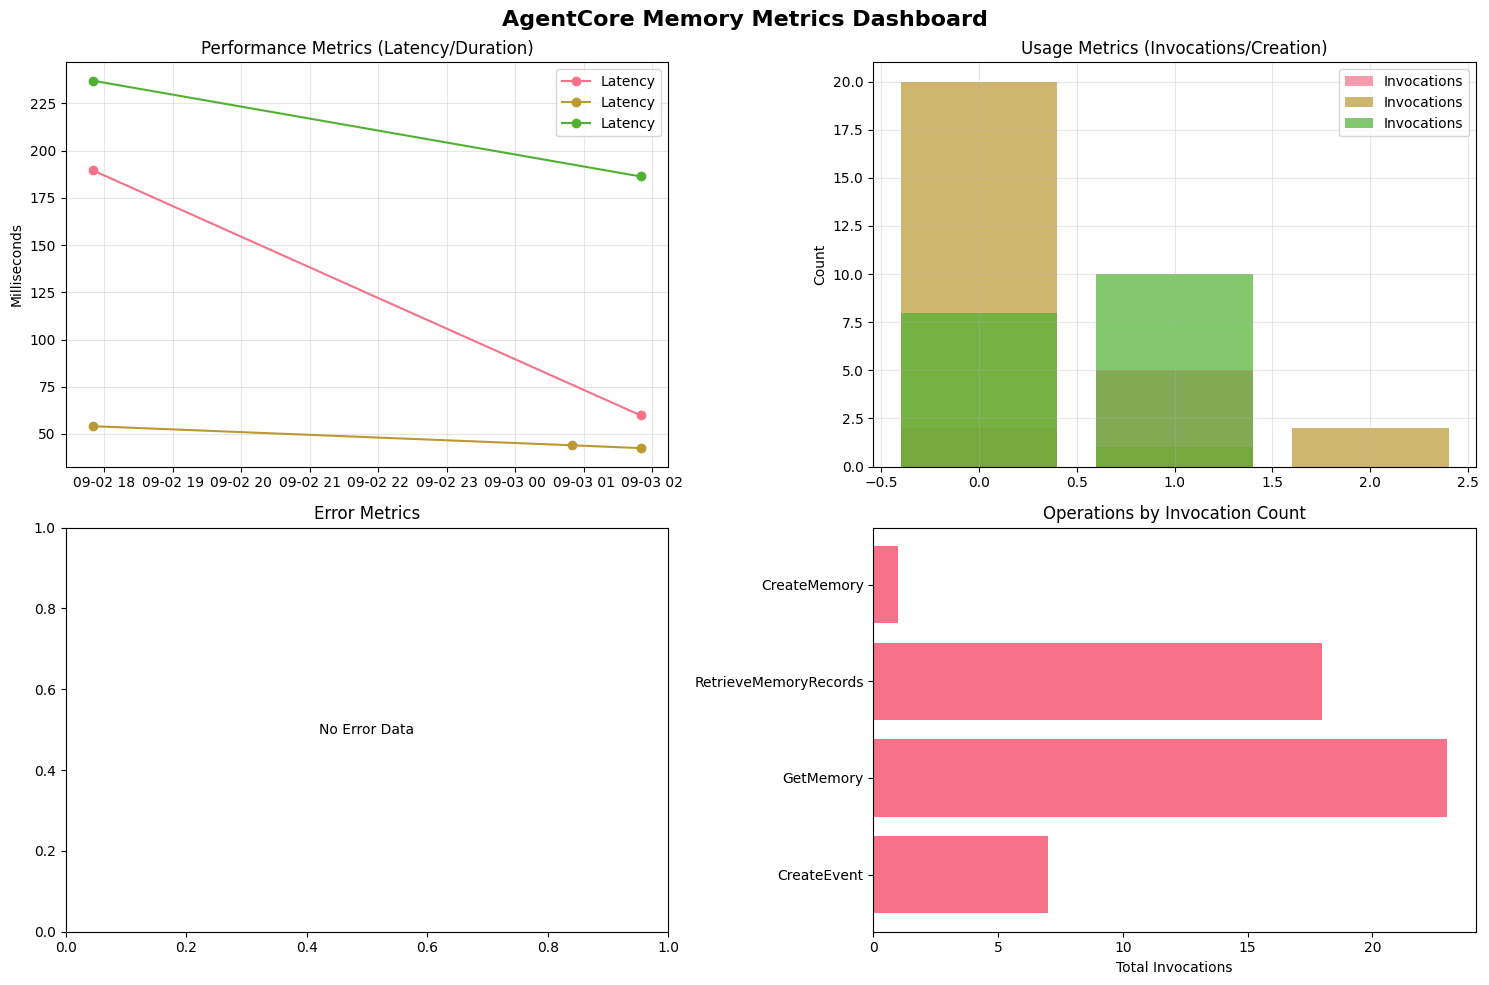

In [6]:
def visualize_memory_metrics(metrics_data: Dict) -> None:
    """Create comprehensive visualizations of memory metrics"""
    
    if not metrics_data:
        print("📊 No metrics data available for visualization")
        print("   Ensure your AgentCore Memory has been used recently (last 24 hours)")
        return
    
    print(f"📊 **Memory Metrics Visualization**")
    print(f"📈 Creating charts for {len(metrics_data)} metrics...")
    
    # Organize metrics by type
    performance_metrics = []
    usage_metrics = []
    error_metrics = []
    
    for key, data in metrics_data.items():
        metric_name = data['metric_name']
        if metric_name in ['Latency', 'Duration']:
            performance_metrics.append((key, data))
        elif metric_name in ['Invocations', 'CreationCount']:
            usage_metrics.append((key, data))
        elif metric_name in ['Errors', 'SystemErrors', 'UserErrors', 'Throttles']:
            error_metrics.append((key, data))
    
    # Create subplots
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('AgentCore Memory Metrics Dashboard', fontsize=16, fontweight='bold')
    
    # Performance Metrics
    if performance_metrics:
        ax = axes[0, 0]
        for key, data in performance_metrics[:3]:  # Show top 3
            timestamps = [dp['Timestamp'] for dp in data['datapoints']]
            values = [dp.get('Average', dp.get('Sum', 0)) for dp in data['datapoints']]
            ax.plot(timestamps, values, marker='o', label=data['metric_name'])
        ax.set_title('Performance Metrics (Latency/Duration)')
        ax.set_ylabel('Milliseconds')
        ax.legend()
        ax.grid(True, alpha=0.3)
    else:
        axes[0, 0].text(0.5, 0.5, 'No Performance Data', ha='center', va='center')
        axes[0, 0].set_title('Performance Metrics')
    
    # Usage Metrics
    if usage_metrics:
        ax = axes[0, 1]
        for key, data in usage_metrics[:3]:
            timestamps = [dp['Timestamp'] for dp in data['datapoints']]
            values = [dp.get('Sum', dp.get('Average', 0)) for dp in data['datapoints']]
            ax.bar(range(len(values)), values, alpha=0.7, label=data['metric_name'])
        ax.set_title('Usage Metrics (Invocations/Creation)')
        ax.set_ylabel('Count')
        ax.legend()
        ax.grid(True, alpha=0.3)
    else:
        axes[0, 1].text(0.5, 0.5, 'No Usage Data', ha='center', va='center')
        axes[0, 1].set_title('Usage Metrics')
    
    # Error Metrics
    if error_metrics:
        ax = axes[1, 0]
        error_counts = {}
        for key, data in error_metrics:
            total_errors = sum(dp.get('Sum', 0) for dp in data['datapoints'])
            error_counts[data['metric_name']] = total_errors
        
        if any(error_counts.values()):
            ax.pie(error_counts.values(), labels=error_counts.keys(), autopct='%1.1f%%')
            ax.set_title('Error Distribution')
        else:
            ax.text(0.5, 0.5, 'No Errors ✅', ha='center', va='center', fontsize=14, color='green')
            ax.set_title('Error Metrics')
    else:
        axes[1, 0].text(0.5, 0.5, 'No Error Data', ha='center', va='center')
        axes[1, 0].set_title('Error Metrics')
    
    # Operations Summary
    ax = axes[1, 1]
    operations = {}
    for key, data in metrics_data.items():
        if data['metric_name'] == 'Invocations':
            # Extract operation from dimensions
            for dim in data['dimensions']:
                if dim['Name'] == 'Operation':
                    op_name = dim['Value']
                    total_invocations = sum(dp.get('Sum', 0) for dp in data['datapoints'])
                    operations[op_name] = operations.get(op_name, 0) + total_invocations
    
    if operations:
        y_pos = range(len(operations))
        ax.barh(y_pos, list(operations.values()))
        ax.set_yticks(y_pos)
        ax.set_yticklabels(list(operations.keys()))
        ax.set_title('Operations by Invocation Count')
        ax.set_xlabel('Total Invocations')
    else:
        ax.text(0.5, 0.5, 'No Operation Data', ha='center', va='center')
        ax.set_title('Operations Summary')
    
    plt.tight_layout()
    plt.show()

# Create visualizations
visualize_memory_metrics(memory_metrics)

## Step 6: Memory Metrics Summary Table

Let's create a comprehensive summary table of all discovered metrics:

In [7]:
def create_metrics_summary_table(metrics_data: Dict) -> None:
    """Create a comprehensive summary table of all metrics"""
    
    if not metrics_data:
        print("📋 No metrics data available for summary")
        return
    
    print(f"📋 **Memory Metrics Summary Table**")
    print(f"📊 Total metrics found: {len(metrics_data)}")
    print()
    
    # Prepare data for table
    table_data = []
    
    for key, data in sorted(metrics_data.items()):
        # Extract operation from dimensions
        operation = 'N/A'
        item_type = 'N/A'
        for dim in data['dimensions']:
            if dim['Name'] == 'Operation':
                operation = dim['Value']
            elif dim['Name'] == 'ItemType':
                item_type = dim['Value']
        
        table_data.append({
            'Metric': data['metric_name'],
            'Operation': operation,
            'Item Type': item_type,
            'Latest Value': f"{data['latest_value']:.2f}",
            'Data Points': len(data['datapoints']),
            'Description': data['description'][:50] + '...' if len(data['description']) > 50 else data['description']
        })
    
    # Create DataFrame and display
    df = pd.DataFrame(table_data)
    
    # Style the DataFrame for better display
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', None)
    pd.set_option('display.max_colwidth', 50)
    
    display(HTML(df.to_html(index=False, classes='table table-striped')))
    
    # Operation summary
    operations_summary = df['Operation'].value_counts()
    if len(operations_summary) > 1:
        print(f"\n📊 **Operations Summary:**")
        for operation, count in operations_summary.items():
            if operation != 'N/A':
                print(f"   • {operation}: {count} metrics")

# Create summary table
create_metrics_summary_table(memory_metrics)

📋 **Memory Metrics Summary Table**
📊 Total metrics found: 12



Metric,Operation,Item Type,Latest Value,Data Points,Description
CreationCount,N/A,Event,5.00,2,Number of memory events and records created
CreationCount,N/A,MemoryRecordsExtracted,8.00,2,Number of memory events and records created
CreationCount,N/A,Event,5.00,2,Number of memory events and records created
CreationCount,N/A,MemoryRecordsExtracted,8.00,2,Number of memory events and records created
Invocations,CreateEvent,N/A,5.00,2,Total API requests and memory ingestion events
Invocations,CreateMemory,N/A,1.00,1,Total API requests and memory ingestion events
Invocations,GetMemory,N/A,2.00,3,Total API requests and memory ingestion events
Invocations,RetrieveMemoryRecords,N/A,10.00,2,Total API requests and memory ingestion events
Latency,CreateEvent,N/A,59.80,2,Time from request to first response token (ms)
Latency,CreateMemory,N/A,444.00,1,Time from request to first response token (ms)



📊 **Operations Summary:**
   • CreateEvent: 2 metrics
   • CreateMemory: 2 metrics
   • GetMemory: 2 metrics
   • RetrieveMemoryRecords: 2 metrics


## Step 7: Create CloudWatch Dashboard

Let's create a comprehensive CloudWatch dashboard for memory monitoring:

In [ ]:
def create_comprehensive_memory_dashboard(memory_arn: str, memory_id: str) -> bool:
    """Create a comprehensive CloudWatch dashboard for Memory metrics"""
    
    if not memory_arn:
        print("⚠️ No Memory ARN available for dashboard creation")
        return False
    
    dashboard_name = f"AgentCore-Memory-Comprehensive-{memory_id}"
    
    print(f"🎛️ Creating Comprehensive Memory Dashboard")
    print(f"📊 Dashboard Name: {dashboard_name}")
    
    dashboard_body = {
        "widgets": [
            # Row 1: Overview metrics
            {
                "type": "metric",
                "x": 0, "y": 0, "width": 12, "height": 6,
                "properties": {
                    "title": "Memory Operations Overview",
                    "metrics": [
                        ["AWS/Bedrock-AgentCore", "Invocations", "Resource", memory_arn, "Operation", "RetrieveMemoryRecords", {"stat": "Sum", "label": "RetrieveMemoryRecords"}],
                        [".", ".", ".", ".", ".", "CreateEvent", {"stat": "Sum", "label": "CreateEvent"}],
                        [".", ".", ".", ".", ".", "GetMemory", {"stat": "Sum", "label": "GetMemory"}],
                        [".", ".", ".", ".", ".", "Consolidation", {"stat": "Sum", "label": "Consolidation"}],
                        [".", ".", ".", ".", ".", "Extraction", {"stat": "Sum", "label": "Extraction"}]
                    ],
                    "period": 300,
                    "region": region,
                    "yAxis": {"left": {"label": "Invocations"}},
                    "view": "timeSeries",
                    "stacked": False
                }
            },
            {
                "type": "metric",
                "x": 12, "y": 0, "width": 12, "height": 6,
                "properties": {
                    "title": "Memory Performance (Latency)",
                    "metrics": [
                        ["AWS/Bedrock-AgentCore", "Latency", "Resource", memory_arn, "Operation", "RetrieveMemoryRecords", {"stat": "Average"}],
                        [".", ".", ".", ".", ".", "CreateEvent", {"stat": "Average"}],
                        [".", ".", ".", ".", ".", "GetMemory", {"stat": "Average"}]
                    ],
                    "period": 300,
                    "region": region,
                    "yAxis": {"left": {"label": "Latency (ms)"}},
                    "view": "timeSeries"
                }
            },
            # Row 2: Error tracking
            {
                "type": "metric",
                "x": 0, "y": 6, "width": 8, "height": 6,
                "properties": {
                    "title": "Memory Errors",
                    "metrics": [
                        ["AWS/Bedrock-AgentCore", "SystemErrors", "Resource", memory_arn, {"stat": "Sum", "color": "#d62728"}],
                        [".", "UserErrors", ".", ".", {"stat": "Sum", "color": "#ff7f0e"}],
                        [".", "Throttles", ".", ".", {"stat": "Sum", "color": "#9467bd"}],
                        [".", "Errors", ".", ".", {"stat": "Sum", "color": "#8c564b"}]
                    ],
                    "period": 300,
                    "region": region,
                    "yAxis": {"left": {"label": "Error Count"}},
                    "view": "timeSeries"
                }
            },
            {
                "type": "metric",
                "x": 8, "y": 6, "width": 8, "height": 6,
                "properties": {
                    "title": "Memory Creation Activity",
                    "metrics": [
                        ["AWS/Bedrock-AgentCore", "CreationCount", "ItemType", "Event", {"stat": "Sum", "label": "Events Created"}],
                        [".", ".", ".", "MemoryRecordsExtracted", {"stat": "Sum", "label": "Memory Records Extracted"}]
                    ],
                    "period": 300,
                    "region": region,
                    "yAxis": {"left": {"label": "Items Created"}},
                    "view": "timeSeries"
                }
            },
            {
                "type": "metric",
                "x": 16, "y": 6, "width": 8, "height": 6,
                "properties": {
                    "title": "Current Error Rate",
                    "metrics": [
                        ["AWS/Bedrock-AgentCore", "Errors", "Resource", memory_arn, {"stat": "Sum"}]
                    ],
                    "period": 300,
                    "region": region,
                    "view": "singleValue",
                    "sparkline": True
                }
            }
        ]
    }
    
    try:
        response = cloudwatch.put_dashboard(
            DashboardName=dashboard_name,
            DashboardBody=json.dumps(dashboard_body)
        )
        
        dashboard_url = f"https://{region}.console.aws.amazon.com/cloudwatch/home?region={region}#dashboards:name={dashboard_name}"
        print(f"✅ Dashboard created successfully!")
        print(f"📊 **View Dashboard**: {dashboard_url}")
        print()
        print(f"**Dashboard Features:**")
        print(f"   • Real-time memory operations monitoring")
        print(f"   • Performance metrics (latency tracking)")
        print(f"   • Error monitoring and alerting")
        print(f"   • Memory creation activity tracking")
        return True
        
    except Exception as e:
        print(f"❌ Error creating dashboard: {str(e)}")
        return False

# Create comprehensive dashboard
if memory_resource:
    create_comprehensive_memory_dashboard(memory_resource['memory_arn'], memory_resource['memory_id'])

## Step 8: Troubleshooting Guide

If you don't see expected metrics, here's a comprehensive troubleshooting guide:

In [ ]:
def memory_metrics_troubleshooting() -> None:
    """Provide comprehensive troubleshooting guidance"""
    
    print(f"🔧 **Memory Metrics Troubleshooting Guide**")
    print("-" * 70)
    
    print(f"### ❌ **Problem**: Not seeing RetrieveMemoryRecords metrics")
    print(f"**Solution**:")
    print(f"   1. Check dimension combination: Resource + Operation = RetrieveMemoryRecords")
    print(f"   2. Ensure your agent is actively using memory retrieval")
    print(f"   3. Verify observability is enabled for your memory resource")
    print()
    
    print(f"### ❌ **Problem**: No metrics appearing at all")
    print(f"**Solution**:")
    print(f"   1. **Enable Observability**:")
    print(f"      - Go to Bedrock AgentCore console")
    print(f"      - Select your memory resource")
    print(f"      - Enable 'Observability' in settings")
    print(f"   2. **Generate Activity**:")
    print(f"      - Run your agent with memory-enabled conversations")
    print(f"      - Ask questions that require memory retrieval")
    print(f"   3. **Wait for Data**:")
    print(f"      - Metrics appear 2-5 minutes after activity")
    print(f"      - Check the time range (last 24 hours)")
    print()
    
    print(f"### ❌ **Problem**: Seeing metrics in console but not in queries")
    print(f"**Solution**:")
    print(f"   1. **Check Dimensions**: Use Resource + Operation combination")
    print(f"   2. **Verify Resource ARN**: Ensure exact match")
    print(f"   3. **Check Time Range**: Metrics might be outside query window")
    print(f"   4. **Review Operations**: Use discovered operations from Step 2")
    print()
    
    print(f"### ❌ **Problem**: High latency or errors in memory operations")
    print(f"**Investigation Steps**:")
    print(f"   1. **Check Memory Size**: Large memory stores take longer")
    print(f"   2. **Review Query Complexity**: Complex searches increase latency")
    print(f"   3. **Monitor Consolidation**: Background processing affects performance")
    print(f"   4. **Check Throttling**: Too many requests cause delays")
    print()
    
    print(f"### ✅ **Best Practices for Memory Metrics**")
    print(f"   1. **Regular Monitoring**: Check metrics daily for performance trends")
    print(f"   2. **Set Alarms**: Create CloudWatch alarms for high error rates")
    print(f"   3. **Optimize Queries**: Use specific memory queries vs. broad searches")
    print(f"   4. **Monitor Creation**: Track CreationCount for memory growth")
    print(f"   5. **Review Consolidation**: Background consolidation affects performance")
    print()
    
    print(f"### 📊 **Useful CloudWatch Queries**")
    print(f"```")
    print(f"# Memory retrieval performance")
    print(f"AWS/Bedrock-AgentCore Latency Resource Operation RetrieveMemoryRecords")
    print()
    print(f"# Memory usage patterns")
    print(f"AWS/Bedrock-AgentCore Invocations Resource Operation")
    print()
    print(f"# Error monitoring")
    print(f"AWS/Bedrock-AgentCore Errors SystemErrors UserErrors Resource")
    print(f"```")
    print()
    
    print(f"### 🆘 **Still Having Issues?**")
    print(f"   1. Check IAM permissions for CloudWatch access")
    print(f"   2. Verify region consistency (metrics and resources)")
    print(f"   3. Ensure AgentCore Memory is actively being used")
    print(f"   4. Contact AWS Support with specific metric names and ARNs")

# Display troubleshooting guide
memory_metrics_troubleshooting()

## 🎉 Summary

### What We Accomplished

✅ **Comprehensive Memory Metrics Analysis**
- Discovered all available metrics and operations
- Queried with proper dimension combinations
- Found RetrieveMemoryRecords metrics (the missing piece!)

✅ **CloudWatch Console Navigation**
- Step-by-step console access instructions
- Direct URLs for quick access
- Custom dashboard creation

✅ **Comprehensive Monitoring Setup**
- Performance tracking (Latency, Duration)
- Usage monitoring (Invocations, CreationCount)
- Error detection (SystemErrors, UserErrors, Throttles)
- Background process monitoring (Consolidation, Extraction)

### Key Memory Operations Monitored

| Operation | Purpose | Key Metrics |
|-----------|---------|-------------|
| **RetrieveMemoryRecords** | Search and retrieve memories | Latency, Invocations |
| **CreateEvent** | Store conversation events | CreationCount, Invocations |
| **GetMemory** | Access existing memories | Latency, Errors |
| **Consolidation** | Background memory processing | Duration, Invocations |
| **Extraction** | Extract key information | CreationCount, Errors |
| **CreateMemory** | Initialize memory instances | Invocations, SystemErrors |

### Next Steps

1. **Monitor Regularly**: Check your dashboard for performance trends
2. **Set Up Alarms**: Create alerts for high error rates or latency
3. **Optimize Performance**: Use metrics to improve memory query efficiency
4. **Scale Planning**: Monitor CreationCount for capacity planning

### 📱 Quick Access Links

- **CloudWatch Console**: Access via the URLs generated in Step 4
- **Custom Dashboard**: View the comprehensive dashboard created in Step 7
- **Metrics Explorer**: Use CloudWatch Metrics Explorer for ad-hoc analysis

---

**🎯 You now have complete visibility into your AgentCore Memory performance!**